# Humanoid standup with a feet end-reference and rank-based MPPI

Companion to `hopper_waypoint_mppi.ipynb`, applied to the G1 humanoid standup task —
with a **single end reference point** and no intermediates. The reference point is
**the humanoid's feet**: a sphere centered on the feet's location (sized to cover the
feet region). The humanoid is first collapsed to the ground by a scripted fold, then
MPPIv2 samples rollouts scored by the standup cost, but — as in the hopper notebook —
selection replaces the plain softmax with a **rank in [0, 1]**: 1 when a rollout's
terminal feet midpoint sits at the reference center, 0 when the feet end outside the
sphere. The top-ranked trajectory is chosen; trajectories sharing the same high rank
are combined with a softmax. The result: the humanoid stands up *in place*, keeping
its feet at the end reference, rendered as an HTML video.

In [2]:
import mujoco
import numpy as np

from analytic_mppi.tasks.g1_standup import G1StandupTask
from analytic_mppi.dynamics import MujocoBackend
from analytic_mppi.controllers import MPPIv2
from analytic_mppi.controllers.sampling_base import Trajectory

# ---- end reference point: the humanoid's feet ----
R_FEET = 0.3             # sphere radius ~ the feet region (G1 foot is ~0.25 long)

# ---- MPPI settings ----
PLAN_HORIZON = 0.8       # seconds
NUM_SAMPLES = 256
NUM_KNOTS = 6
ITERATIONS = 2
NOISE = 0.15
TEMP = 0.05
SPLINE = "cubic"
SEED = 0

# ---- steering / selection ----
W_FEET = 5.0             # weight of the feet-to-reference steering cost term
TIE_TOL = 0.15           # ranks within this of the max count as "same high rank"

COLLAPSE_FOLD_T = 3.0    # scripted fold duration (s)
COLLAPSE_SETTLE_T = 2.0  # settle after releasing the fold (s)
T_MAX = 15.0             # standup budget (s)

## Collapse phase and reference placement

Zero control holds the G1 upright (its position actuators target the `stand` pose), so
a scripted fold — hips and knees commanded into deep flexion for 3 s, then released —
drops it flat on the ground, from where zero control cannot recover. The **end
reference point is placed at the feet**: the midpoint of the two foot sites in the
collapsed state.

In [3]:
plain_task = G1StandupTask()
backend0 = MujocoBackend(plain_task.model_path)

fold = np.zeros(backend0.nu)
fold[[0, 6]] = -1.8      # hip pitch
fold[[3, 9]] = 2.6       # knees
fold[[4, 10]] = -0.6     # ankle pitch

collapse_states = []
n_fold = round(COLLAPSE_FOLD_T / backend0.dt)
n_settle = round(COLLAPSE_SETTLE_T / backend0.dt)
for step in range(n_fold + n_settle):
    backend0.step(fold if step < n_fold else np.zeros(backend0.nu))
    collapse_states.append(backend0.get_state().copy())
state0 = backend0.get_state().copy()

lf_site = mujoco.mj_name2id(backend0.model, mujoco.mjtObj.mjOBJ_SITE, "left_foot")
rf_site = mujoco.mj_name2id(backend0.model, mujoco.mjtObj.mjOBJ_SITE, "right_foot")
feet_ref = (backend0.data.site_xpos[lf_site] + backend0.data.site_xpos[rf_site]) / 2.0

print(f"collapsed: pelvis z = {backend0.data.qpos[2]:.3f}, "
      f"torso z = {backend0.data.sensordata[plain_task._torso_pos_adr + 2]:.3f}")
print(f"end reference point (feet midpoint) = {np.round(feet_ref, 3)}, R = {R_FEET}")

collapsed: pelvis z = 0.055, torso z = 0.013
end reference point (feet midpoint) = [0.396 0.04  0.05 ], R = 0.3


## Augmented model

The rank needs each rollout's feet positions, which `mujoco.rollout` only exports via
sensors — the scene has none for the feet. `MjSpec` adds two `framepos` sensors on the
foot sites (appended after the existing sensors, so their addresses are unchanged),
plus the reference sphere as a visual-only site. Sensors and sites don't affect the
dynamics, so planning, execution, and rendering can all share this one model.

In [4]:
spec = mujoco.MjSpec.from_file(str(plain_task.model_path))
for nm, site in (("left_foot_pos", "left_foot"), ("right_foot_pos", "right_foot")):
    s = spec.add_sensor()
    s.name = nm
    s.type = mujoco.mjtSensor.mjSENS_FRAMEPOS
    s.objtype = mujoco.mjtObj.mjOBJ_SITE
    s.objname = site
spec.worldbody.add_site(name="feet_ref", pos=feet_ref.tolist(), size=[R_FEET] * 3,
                        rgba=[0.9, 0.35, 0.1, 0.3])
spec.worldbody.add_site(name="feet_ref_center", pos=feet_ref.tolist(),
                        size=[0.04] * 3, rgba=[0.9, 0.35, 0.1, 1.0])
model = spec.compile()


class ModelBackend(MujocoBackend):
    """MujocoBackend built from an already-compiled model instead of a path."""

    def __init__(self, model, nthread=None):
        import os
        self.model_path = None
        self.model = model
        self.data = mujoco.MjData(model)
        mujoco.mj_forward(model, self.data)
        self.nthread = nthread if nthread is not None else max(1, os.cpu_count() or 1)
        self._thread_data = [mujoco.MjData(model) for _ in range(self.nthread)]
        self.nq = int(model.nq)
        self.nv = int(model.nv)
        self.nu = int(model.nu)
        self.nsensordata = int(model.nsensordata)
        self.nstate = int(mujoco.mj_stateSize(model, int(self.state_spec)))
        self.dt = float(model.opt.timestep)
        self.qpos_slice = slice(1, 1 + self.nq)
        self.qvel_slice = slice(1 + self.nq, 1 + self.nq + self.nv)

## Task: standup cost + feet steering

`G1FeetRefTask` keeps the standup terms (uprightness, torso height, nominal pose) and
appends a quadratic term pulling the feet midpoint toward the reference center — the
same role the waypoint term played for the hopper.

In [5]:
class G1FeetRefTask(G1StandupTask):
    cost_term_names = G1StandupTask.cost_term_names + ["feet_cost"]

    def __init__(self, model, feet_ref, *, feet_radius, w_feet):
        super().__init__()
        # swap in the augmented model (same dynamics; extra sensors + visual sites)
        self.mj_model = model
        self.nsensordata = int(model.nsensordata)
        self._lf_adr = int(model.sensor_adr[
            mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "left_foot_pos")])
        self._rf_adr = int(model.sensor_adr[
            mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_SENSOR, "right_foot_pos")])
        self.feet_ref = np.asarray(feet_ref, dtype=np.float64)
        self.feet_radius = float(feet_radius)
        self.w_feet = float(w_feet)

    def feet_mid(self, sensordata):
        l = sensordata[..., self._lf_adr:self._lf_adr + 3]
        r = sensordata[..., self._rf_adr:self._rf_adr + 3]
        return 0.5 * (l + r)

    def feet_dist(self, sensordata):
        return np.linalg.norm(self.feet_mid(sensordata) - self.feet_ref, axis=-1)

    def running_cost_terms(self, qpos, qvel, sensordata, u):
        base = super().running_cost_terms(qpos, qvel, sensordata, u)
        feet = self.w_feet * self.feet_dist(sensordata) ** 2
        return np.concatenate([base, feet[..., None]], axis=-1)

    def terminal_cost_terms(self, qpos, qvel, sensordata):
        base = super().terminal_cost_terms(qpos, qvel, sensordata)
        feet = self.w_feet * self.feet_dist(sensordata) ** 2
        return np.concatenate([base, feet[..., None]], axis=-1)

## Controller: rank in [0, 1] on the feet, instead of the plain softmax

Identical selection rule to the hopper notebook, with the feet midpoint as the ranked
quantity: `rank = clip(1 - dist(feet_end, reference_center) / R, 0, 1)` — 1 with the
feet at the center of the reference, 0 with the feet outside the sphere. Highest rank
wins; ranks within `TIE_TOL` of the max are combined with a softmax (MPPI weights over
their scores); if no rollout's feet end inside the sphere, it falls back to the
standard MPPIv2 softmax.

In [6]:
class FeetRankMPPI(MPPIv2):
    def __init__(self, *args, tie_tol=0.02, **kwargs):
        super().__init__(*args, **kwargs)
        self.tie_tol = float(tie_tol)
        self.last_rank = None
        self.last_mode = None

    def update_mean(self, traj: Trajectory) -> np.ndarray:
        dist = self.task.feet_dist(traj.sensordata[:, -1])   # terminal feet midpoint
        rank = np.clip(1.0 - dist / self.task.feet_radius, 0.0, 1.0)
        self.last_rank = rank

        r_max = rank.max()
        if r_max <= 0.0:                    # no rollout's feet end inside the sphere
            self.last_mode = "softmax-fallback"
            return super().update_mean(traj)

        ties = np.flatnonzero(rank >= r_max - self.tie_tol)
        if ties.size == 1:
            self.last_mode = "best"
            return traj.knots[ties[0]].copy()

        self.last_mode = f"tie-softmax({ties.size})"
        s = traj.scores[ties]
        z = -(s - s.min()) / self.temperature
        w = np.exp(z)
        w /= w.sum()
        return (w[:, None, None] * traj.knots[ties]).sum(axis=0)

## Standup run

From the collapsed state, the controller plans toward the end reference at its feet
until the torso reaches the standing target and stays there.

In [7]:
task = G1FeetRefTask(model, feet_ref, feet_radius=R_FEET, w_feet=W_FEET)
backend = ModelBackend(model)
ctrl = FeetRankMPPI(task=task, backend=backend, num_samples=NUM_SAMPLES,
                    noise_level=NOISE, temperature=TEMP, num_knots=NUM_KNOTS,
                    plan_horizon=PLAN_HORIZON, spline_type=SPLINE,
                    iterations=ITERATIONS, seed=SEED, tie_tol=TIE_TOL)

backend.set_state(state0)
ctrl.reset()

stand_states = [backend.get_state().copy()]
torso_z_hist = [float(backend.data.sensordata[task._torso_pos_adr + 2])]
feet_dist_hist = [float(task.feet_dist(backend.data.sensordata))]
mode_counts = {}
t_stood = None

T = round(T_MAX / backend.dt)
for step in range(T):
    u0 = ctrl.act(backend.get_state())
    backend.step(u0)

    stand_states.append(backend.get_state().copy())
    torso_z_hist.append(float(backend.data.sensordata[task._torso_pos_adr + 2]))
    feet_dist_hist.append(float(task.feet_dist(backend.data.sensordata)))
    mode_counts[ctrl.last_mode] = mode_counts.get(ctrl.last_mode, 0) + 1

    t_now = (step + 1) * backend.dt
    if t_stood is None and torso_z_hist[-1] >= 0.85:
        t_stood = t_now
        print(f"t={t_now:5.2f}s  torso z reached {torso_z_hist[-1]:.2f} - standing")
    if step % 100 == 99:
        print(f"t={t_now:5.2f}s  torso z={torso_z_hist[-1]:.3f}  "
              f"feet dist={feet_dist_hist[-1]:.3f}  mode={ctrl.last_mode}  "
              f"rank_max={ctrl.last_rank.max():.2f}")

print(f"\nfinal: torso z = {torso_z_hist[-1]:.3f} (target {task.target_height}), "
      f"feet {feet_dist_hist[-1]:.3f} m from the reference center (R = {R_FEET})")
print("selection modes used:", dict(sorted(mode_counts.items())))

t= 1.88s  torso z reached 0.86 - standing
t= 2.00s  torso z=0.882  feet dist=0.118  mode=tie-softmax(67)  rank_max=0.97
t= 4.00s  torso z=0.925  feet dist=0.097  mode=tie-softmax(113)  rank_max=0.97
t= 6.00s  torso z=0.956  feet dist=0.108  mode=tie-softmax(52)  rank_max=0.96
t= 8.00s  torso z=0.935  feet dist=0.053  mode=tie-softmax(64)  rank_max=0.98
t=10.00s  torso z=0.928  feet dist=0.119  mode=tie-softmax(18)  rank_max=0.96
t=12.00s  torso z=0.936  feet dist=0.098  mode=tie-softmax(32)  rank_max=0.95
t=14.00s  torso z=0.906  feet dist=0.089  mode=tie-softmax(96)  rank_max=0.97

final: torso z = 0.919 (target 0.9), feet 0.127 m from the reference center (R = 0.3)
selection modes used: {'tie-softmax(10)': 4, 'tie-softmax(101)': 2, 'tie-softmax(102)': 4, 'tie-softmax(103)': 3, 'tie-softmax(104)': 2, 'tie-softmax(105)': 1, 'tie-softmax(107)': 3, 'tie-softmax(108)': 1, 'tie-softmax(11)': 4, 'tie-softmax(110)': 2, 'tie-softmax(111)': 1, 'tie-softmax(112)': 1, 'tie-softmax(113)': 3, 'tie

## HTML render

The full episode — scripted collapse, then the rank-MPPI standup — replayed on the
augmented model, so the orange feet end-reference sphere (with its center dot) is
visible throughout.

In [8]:
import base64, os, tempfile

import imageio
from IPython.display import HTML, display


def render_standup_html(states, *, width=480, height=320, stride=3, min_seconds=20.0):
    data = mujoco.MjData(model)
    qpos = states[:, 1:1 + model.nq]
    qvel = states[:, 1 + model.nq:1 + model.nq + model.nv]

    cam = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(model, cam)
    cam.distance, cam.elevation, cam.azimuth = 3.0, -15.0, 135.0
    cam.lookat[:] = [feet_ref[0], feet_ref[1], 0.6]

    r = mujoco.Renderer(model, height=height, width=width)
    frames = []
    for qp, qv in zip(qpos[::stride], qvel[::stride]):
        data.qpos[:] = qp
        data.qvel[:] = qv
        mujoco.mj_forward(model, data)
        r.update_scene(data, cam)
        frames.append(r.render())
    r.close()

    fps = min(60.0, max(1.0, len(frames) / float(min_seconds)))
    with tempfile.NamedTemporaryFile(suffix=".mp4", delete=False) as f:
        path = f.name
    imageio.mimwrite(path, np.asarray(frames), fps=fps, codec="libx264")
    b64 = base64.b64encode(open(path, "rb").read()).decode()
    os.remove(path)
    return (f'<figure style="display:inline-block;text-align:center">'
            f'<figcaption><b>G1 standup at the feet end-reference</b> &middot; '
            f'{len(frames) / fps:.0f}s (collapse, then standup)</figcaption>'
            f'<video controls autoplay loop muted width="{width}">'
            f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
            f'</video></figure>')


all_states = np.asarray(collapse_states + stand_states)
display(HTML(render_standup_html(all_states)))

libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init
No plugins found, falling back on no decorations



## Progress summary

Torso height and the feet's distance to the reference center over the whole episode
(both in meters, one axis). The gray span is the scripted collapse; after it, the
controller raises the torso to the target while the feet stay well inside the
reference sphere.

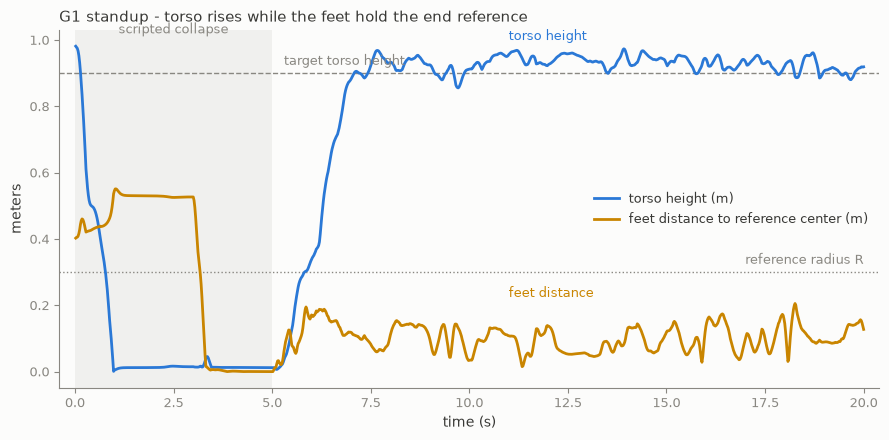

In [9]:
import matplotlib.pyplot as plt

INK, MUTED = "#383835", "#898781"
BLUE, AMBER = "#2a78d6", "#c98500"
SURFACE = "#fcfcfb"

dt = backend.dt
t_collapse = np.arange(1, len(collapse_states) + 1) * dt
t_stand = t_collapse[-1] + np.arange(len(torso_z_hist)) * dt

# torso z during the collapse phase, read back from the recorded states
cq = np.asarray(collapse_states)[:, 1:1 + model.nq]
d_tmp = mujoco.MjData(model)
collapse_torso_z, collapse_feet_dist = [], []
for qp in cq:
    d_tmp.qpos[:] = qp
    mujoco.mj_forward(model, d_tmp)
    collapse_torso_z.append(float(d_tmp.sensordata[task._torso_pos_adr + 2]))
    collapse_feet_dist.append(float(task.feet_dist(d_tmp.sensordata)))

t_all = np.concatenate([t_collapse, t_stand])
torso_all = np.concatenate([collapse_torso_z, torso_z_hist])
feet_all = np.concatenate([collapse_feet_dist, feet_dist_hist])

fig, ax = plt.subplots(figsize=(9, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

ax.axvspan(0, t_collapse[-1], color=MUTED, alpha=0.10, lw=0)
ax.text(t_collapse[-1] / 2, 1.02, "scripted collapse", ha="center", color=MUTED, fontsize=9)
ax.axhline(task.target_height, color=MUTED, ls="--", lw=1)
ax.text(t_collapse[-1] + 0.3, task.target_height + 0.025, "target torso height",
        ha="left", color=MUTED, fontsize=9)
ax.axhline(R_FEET, color=MUTED, ls=":", lw=1)
ax.text(t_all[-1], R_FEET + 0.025, "reference radius R", ha="right", color=MUTED, fontsize=9)

ax.plot(t_all, torso_all, color=BLUE, lw=2, label="torso height (m)")
ax.plot(t_all, feet_all, color=AMBER, lw=2, label="feet distance to reference center (m)")
ax.text(11.0, 1.0, "torso height", color=BLUE, fontsize=9)
ax.text(11.0, 0.225, "feet distance", color=AMBER, fontsize=9)

ax.legend(loc="center right", frameon=False, fontsize=9, labelcolor=INK)
ax.set_xlabel("time (s)", color=INK)
ax.set_ylabel("meters", color=INK)
ax.set_title("G1 standup - torso rises while the feet hold the end reference",
             color=INK, fontsize=11, loc="left")
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color(MUTED)
ax.tick_params(colors=MUTED, labelsize=9)
ax.margins(x=0.02)
plt.tight_layout()
plt.show()